# RQ1 — Ookla vs NDT7 Threshold Comparison, 9 Countries

Companion to `rq1_thresholds_ookla.ipynb` — same four app-requirement thresholds (Lübben &
Misfeld, 2022), applied to NDT7 broadband/mobile against Ookla fixed/mobile, **for all 9
countries** now that NDT7 covers all of them (Philippines/Malaysia landed 2026-07-29 via the
collaborator ASN relabel in `HANDOFF.md`; Singapore and Indonesia added 2026-07-30).

**Previously this notebook was Thailand+Vietnam only** — that was a real data-availability limit
at the time (NDT7 genuinely didn't exist elsewhere), not a design choice. It no longer applies.

**Both sides now use the `is_reliable`-filtered exports explicitly** — the Ookla branch previously
loaded raw `ookla_*_province_quarterly.csv` with no reliability filter at all (harmless only by
coincidence: every row in this project's Ookla exports happens to already be reliable, verified
2026-07-30). Fixed here so the comparison is correct in principle, not just by luck of the data.

**NDT7 and Ookla `is_reliable` are not the same threshold** — Ookla is `total_tests>=100 &
n_tiles>=5`; NDT7 is `total_tests>=100` alone (NDT7's coordinates are MaxMind city centroids, so
`n_tiles>=5` would zero out the smaller countries — see `docs/paper_draft.md` Contributions). Both
sides here use their own pre-filtered `_reliable_` exports, which already encode this correctly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

COUNTRIES = ['Thailand', 'Vietnam', 'Philippines', 'Singapore', 'Cambodia', 'Laos', 'Malaysia', 'Myanmar', 'Indonesia']

NDT7_FILES = {
    'Thailand':    ('ndt7_broadband_thailand_reliable_province_quarterly.csv',    'ndt7_mobile_thailand_reliable_province_quarterly.csv'),
    'Vietnam':     ('ndt7_broadband_vietnam_reliable_province_quarterly.csv',     'ndt7_mobile_vietnam_reliable_province_quarterly.csv'),
    'Philippines': ('ndt7_broadband_philippines_reliable_province_quarterly.csv', 'ndt7_mobile_philippines_reliable_province_quarterly.csv'),
    'Singapore':   ('ndt7_broadband_singapore_reliable_province_quarterly.csv',   'ndt7_mobile_singapore_reliable_province_quarterly.csv'),
    'Cambodia':    ('ndt7_broadband_cambodia_reliable_province_quarterly.csv',    'ndt7_mobile_cambodia_reliable_province_quarterly.csv'),
    'Laos':        ('ndt7_broadband_laos_reliable_province_quarterly.csv',        'ndt7_mobile_laos_reliable_province_quarterly.csv'),
    'Malaysia':    ('ndt7_broadband_malaysia_reliable_province_quarterly.csv',    'ndt7_mobile_malaysia_reliable_province_quarterly.csv'),
    'Myanmar':     ('ndt7_broadband_myanmar_reliable_province_quarterly.csv',     'ndt7_mobile_myanmar_reliable_province_quarterly.csv'),
    'Indonesia':   ('ndt7_broadband_indonesia_reliable_province_quarterly.csv',   'ndt7_mobile_indonesia_reliable_province_quarterly.csv'),
}

# Thailand's Ookla files are suffix-less (this project's original single-country naming, never renamed)
OOKLA_FILES = {
    'Thailand':    ('ookla_province_quarterly.csv',           'ookla_mobile_province_quarterly.csv'),
    'Vietnam':     ('ookla_vietnam_province_quarterly.csv',    'ookla_mobile_vietnam_province_quarterly.csv'),
    'Philippines': ('ookla_philippines_province_quarterly.csv','ookla_mobile_philippines_province_quarterly.csv'),
    'Singapore':   ('ookla_singapore_province_quarterly.csv', 'ookla_mobile_singapore_province_quarterly.csv'),
    'Cambodia':    ('ookla_cambodia_province_quarterly.csv',  'ookla_mobile_cambodia_province_quarterly.csv'),
    'Laos':        ('ookla_laos_province_quarterly.csv',      'ookla_mobile_laos_province_quarterly.csv'),
    'Malaysia':    ('ookla_malaysia_province_quarterly.csv',  'ookla_mobile_malaysia_province_quarterly.csv'),
    'Myanmar':     ('ookla_myanmar_province_quarterly.csv',   'ookla_mobile_myanmar_province_quarterly.csv'),
    'Indonesia':   ('ookla_indonesia_province_quarterly.csv', 'ookla_mobile_indonesia_province_quarterly.csv'),
}

frames = []
for country in COUNTRIES:
    bb_fn, mb_fn = NDT7_FILES[country]
    for kind, fn in [('fixed', bb_fn), ('mobile', mb_fn)]:
        d = pd.read_csv(EXPORTS / fn)
        d['segment'] = f'{country} — NDT7 {kind}'
        d['country'] = country
        d['source'] = 'NDT7'
        d['kind'] = kind
        frames.append(d)
        print(f'{country} — NDT7 {kind}: {len(d)} rows')

all_df = pd.concat(frames, ignore_index=True)
all_df.shape


Thailand — NDT7 fixed: 872 rows
Thailand — NDT7 mobile: 354 rows
Vietnam — NDT7 fixed: 698 rows
Vietnam — NDT7 mobile: 81 rows
Philippines — NDT7 fixed: 204 rows
Philippines — NDT7 mobile: 151 rows
Singapore — NDT7 fixed: 52 rows
Singapore — NDT7 mobile: 52 rows
Cambodia — NDT7 fixed: 33 rows
Cambodia — NDT7 mobile: 24 rows
Laos — NDT7 fixed: 37 rows
Laos — NDT7 mobile: 24 rows
Malaysia — NDT7 fixed: 165 rows
Malaysia — NDT7 mobile: 69 rows
Myanmar — NDT7 fixed: 76 rows
Myanmar — NDT7 mobile: 37 rows
Indonesia — NDT7 fixed: 402 rows


Indonesia — NDT7 mobile: 361 rows


(3692, 19)

In [2]:
print(all_df.groupby('segment')['is_reliable'].value_counts(dropna=False))
print()
print(all_df.groupby('segment')['total_tests'].median().rename('median_total_tests_per_row'))


segment                    is_reliable
Cambodia — NDT7 fixed      True            33
Cambodia — NDT7 mobile     True            24
Indonesia — NDT7 fixed     True           402
Indonesia — NDT7 mobile    True           361
Laos — NDT7 fixed          True            37
Laos — NDT7 mobile         True            24
Malaysia — NDT7 fixed      True           165
Malaysia — NDT7 mobile     True            69
Myanmar — NDT7 fixed       True            76
Myanmar — NDT7 mobile      True            37
Philippines — NDT7 fixed   True           204
Philippines — NDT7 mobile  True           151
Singapore — NDT7 fixed     True            52
Singapore — NDT7 mobile    True            52
Thailand — NDT7 fixed      True           872
Thailand — NDT7 mobile     True           354
Vietnam — NDT7 fixed       True           698
Vietnam — NDT7 mobile      True            81
Name: count, dtype: int64

segment
Cambodia — NDT7 fixed          4790.0
Cambodia — NDT7 mobile         4307.0
Indonesia — NDT7 fixed

In [3]:
THRESH = {
    'HD (5 Mbps)':          lambda d: d['avg_d_mbps'] >= 5,
    'UHD (25 Mbps)':        lambda d: d['avg_d_mbps'] >= 25,
    'Cloud gaming (44 Mbps + <=25ms)': lambda d: (d['avg_d_mbps'] >= 44) & (d['avg_lat_ms_wt'] <= 25),
    'Voice latency (<=200ms)': lambda d: d['avg_lat_ms_wt'] <= 200,
}

for label, fn in THRESH.items():
    all_df[label] = fn(all_df)

def weighted_pass_rate(df, col):
    if df['total_tests'].sum() == 0 or len(df) == 0:
        return np.nan
    return np.average(df[col], weights=df['total_tests'])

rows = []
for seg in all_df['segment'].unique():
    sub = all_df[all_df['segment'] == seg]
    row = {'segment': seg, 'n_province_quarters': len(sub), 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('segment')
summary_pct = (summary[list(THRESH.keys())] * 100).round(1)
summary_pct[['n_province_quarters', 'n_tests_total']] = summary[['n_province_quarters', 'n_tests_total']]
summary_pct


,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — NDT7 fixed,100.0,100.0,0.0,99.4,872,19990032
Thailand — NDT7 mobile,100.0,12.9,0.0,100.0,354,14810189
Vietnam — NDT7 fixed,100.0,98.5,0.0,98.6,698,11216873
Vietnam — NDT7 mobile,100.0,86.2,0.0,98.4,81,580242
Philippines — NDT7 fixed,100.0,99.9,0.0,100.0,204,104607087
Philippines — NDT7 mobile,100.0,43.1,0.0,100.0,151,40725647
Singapore — NDT7 fixed,100.0,100.0,18.4,100.0,52,8370541
Singapore — NDT7 mobile,100.0,100.0,6.9,100.0,52,3803916
Cambodia — NDT7 fixed,100.0,82.0,0.0,100.0,33,261400


In [4]:
ookla_rows = []
for country in COUNTRIES:
    fixed_fn, mobile_fn = OOKLA_FILES[country]
    for kind, fn in [('fixed', fixed_fn), ('mobile', mobile_fn)]:
        d = pd.read_csv(EXPORTS / fn)
        # is_reliable filter applied explicitly -- previously missing on this branch (fixed 2026-07-30)
        d = d[d['is_reliable'] == True]
        seg = f'{country} — Ookla {kind}'
        for label, f in THRESH.items():
            d[label] = f(d)
        row = {'segment': seg, 'n_province_quarters': len(d), 'n_tests_total': int(d['total_tests'].sum())}
        for label in THRESH:
            row[label] = weighted_pass_rate(d, label)
        ookla_rows.append(row)

ookla_summary = pd.DataFrame(ookla_rows).set_index('segment')
compare = pd.concat([ookla_summary, summary])
compare_pct = (compare[list(THRESH.keys())] * 100).round(1)
compare_pct[['n_province_quarters', 'n_tests_total']] = compare[['n_province_quarters', 'n_tests_total']]
compare_pct


,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — Ookla fixed,100.0,100.0,99.5,100.0,924,20769822
Thailand — Ookla mobile,100.0,100.0,21.6,100.0,924,10451044
Vietnam — Ookla fixed,100.0,100.0,100.0,100.0,768,25884919
Vietnam — Ookla mobile,100.0,100.0,27.9,100.0,757,3488314
Philippines — Ookla fixed,100.0,100.0,92.6,100.0,204,48847570
Philippines — Ookla mobile,100.0,99.6,43.2,100.0,204,7149029
Singapore — Ookla fixed,100.0,100.0,100.0,100.0,60,4473165
Singapore — Ookla mobile,100.0,100.0,48.8,100.0,60,869324
Cambodia — Ookla fixed,100.0,97.6,64.9,100.0,300,2383073


## Fixed broadband — Ookla vs NDT7, all 9 countries

One subplot per threshold, one bar pair (Ookla / NDT7) per country — a 9-country x 4-metric grouped
bar chart in a single plot would be unreadable, so this is small multiples instead.

**Read `n_province_quarters`/`n_tests_total` from the table above before trusting any single bar**
— NDT7 sample sizes vary enormously across countries (Cambodia/Laos/Myanmar are far thinner than
Thailand/Indonesia/Philippines; see Table 1, `docs/paper_draft.md`).


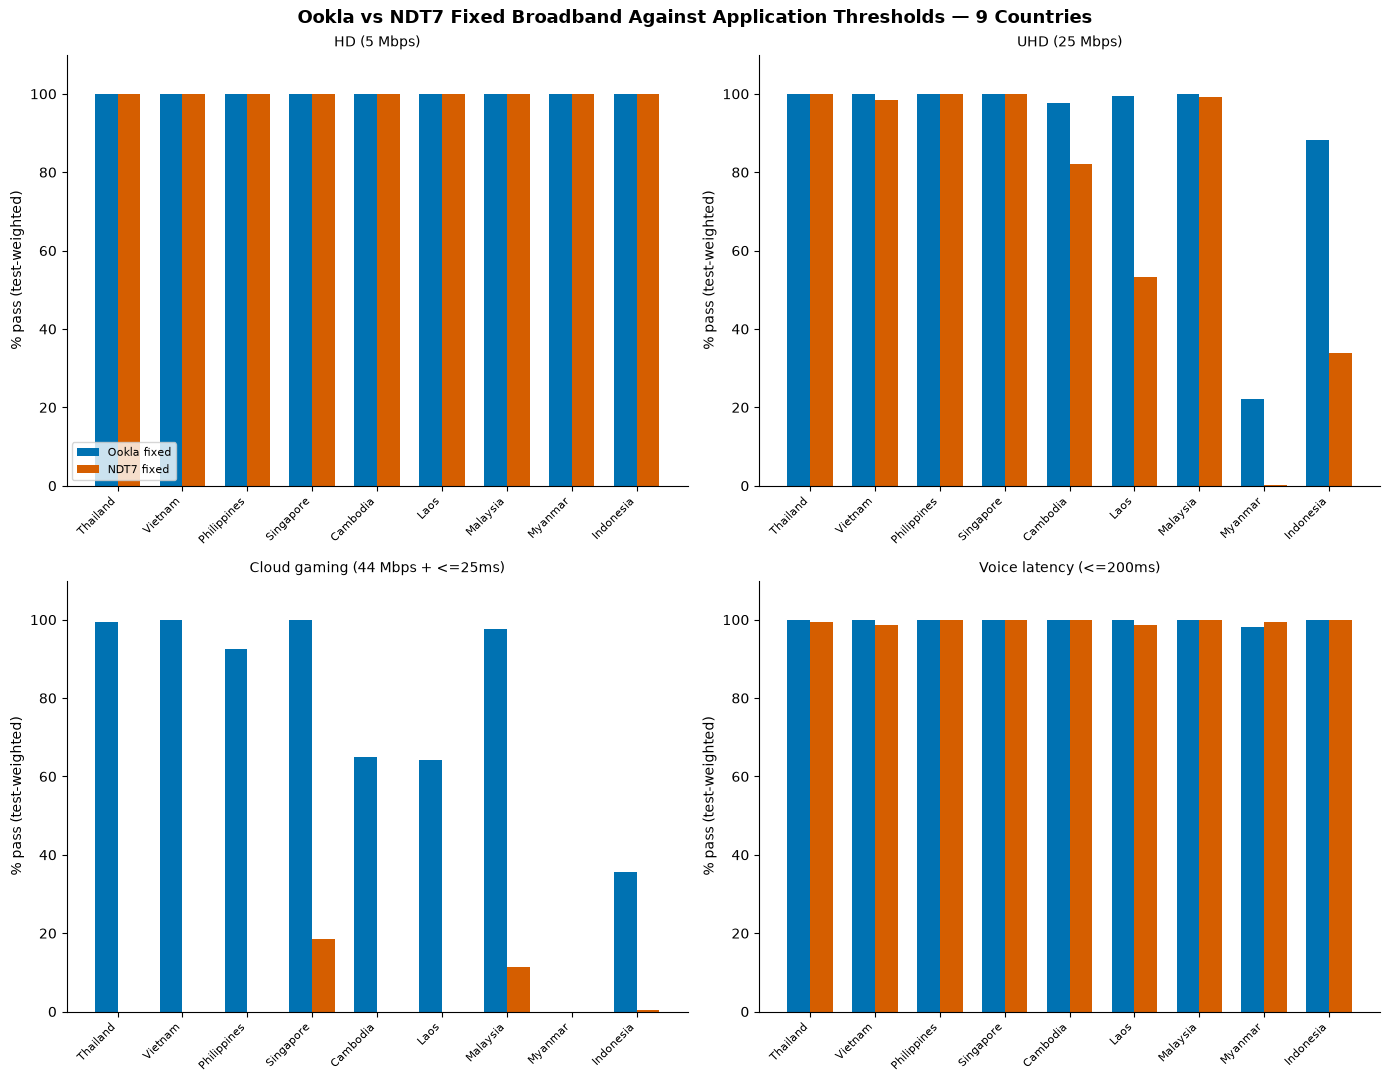

In [5]:
metrics = list(THRESH.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    ookla_vals = [compare_pct.loc[f'{c} — Ookla fixed', metric] for c in COUNTRIES]
    ndt7_vals  = [compare_pct.loc[f'{c} — NDT7 fixed', metric] for c in COUNTRIES]
    x = np.arange(len(COUNTRIES))
    width = 0.35
    ax.bar(x - width/2, ookla_vals, width, label='Ookla fixed', color='#0072B2')
    ax.bar(x + width/2, ndt7_vals, width, label='NDT7 fixed', color='#D55E00')
    ax.set_xticks(x)
    ax.set_xticklabels(COUNTRIES, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_title(metric, fontsize=10)
    ax.set_ylabel('% pass (test-weighted)')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('Ookla vs NDT7 Fixed Broadband Against Application Thresholds — 9 Countries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Mobile — NDT7 only (no Ookla-mobile reload here; see `rq1_thresholds_ookla.ipynb` for Ookla mobile)

Same caveat as above, doubled for mobile — NDT7 mobile samples are thinner than NDT7 fixed for
several countries (see `n_province_quarters` below).


In [6]:
mobile_segs = [f'{c} — NDT7 mobile' for c in COUNTRIES]
compare_pct.loc[[s for s in mobile_segs if s in compare_pct.index]]


,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — NDT7 mobile,100.0,12.9,0.0,100.0,354,14810189
Vietnam — NDT7 mobile,100.0,86.2,0.0,98.4,81,580242
Philippines — NDT7 mobile,100.0,43.1,0.0,100.0,151,40725647
Singapore — NDT7 mobile,100.0,100.0,6.9,100.0,52,3803916
Cambodia — NDT7 mobile,100.0,30.1,0.0,100.0,24,156788
Laos — NDT7 mobile,100.0,4.2,0.0,90.4,24,27318
Malaysia — NDT7 mobile,100.0,96.9,0.0,100.0,69,1147252
Myanmar — NDT7 mobile,100.0,21.8,0.0,97.5,37,189484
Indonesia — NDT7 mobile,100.0,8.9,0.0,100.0,361,53843039


## Cross-source agreement — does the country ranking hold on both platforms?

Rank countries by fixed-broadband UHD pass rate on each source, and check Spearman agreement —
same style of check as `rq_stats_crosscountry.ipynb`'s OLS-coefficient version, but on this
notebook's own pass-rate metric directly.


In [7]:
from scipy import stats as sstats

rank_metric = 'UHD (25 Mbps)'
ookla_vals = pd.Series({c: compare_pct.loc[f'{c} — Ookla fixed', rank_metric] for c in COUNTRIES})
ndt7_vals  = pd.Series({c: compare_pct.loc[f'{c} — NDT7 fixed', rank_metric]  for c in COUNTRIES})

# weighted_pass_rate() returns NaN for zero-test segments -- drop those countries before
# ranking rather than let spearmanr silently return nan with no explanation
valid = ookla_vals.notna() & ndt7_vals.notna()
dropped = [c for c in COUNTRIES if not valid[c]]
if dropped:
    print(f'Dropping {dropped} from rank correlation -- NaN pass rate (zero-test segment)')

ookla_rank = ookla_vals[valid].rank(ascending=False)
ndt7_rank  = ndt7_vals[valid].rank(ascending=False)

rho, p = sstats.spearmanr(ookla_rank, ndt7_rank)
print(f"Spearman rank correlation ({rank_metric} pass rate, Ookla vs NDT7 fixed): rho={rho:.2f}, p={p:.3f}, n={valid.sum()} countries")
pd.DataFrame({'Ookla_rank': ookla_rank, 'NDT7_rank': ndt7_rank}).sort_values('Ookla_rank')

Spearman rank correlation (UHD (25 Mbps) pass rate, Ookla vs NDT7 fixed): rho=0.90, p=0.001, n=9 countries


,Ookla_rank,NDT7_rank
Thailand,3.0,1.5
Vietnam,3.0,5.0
Philippines,3.0,3.0
Singapore,3.0,1.5
Malaysia,3.0,4.0
Laos,6.0,7.0
Cambodia,7.0,6.0
Indonesia,8.0,8.0
Myanmar,9.0,9.0


## Thailand mobile province deep-dive (illustrative — kept from the original 2-country version)

Kept as a worked example of what this kind of drill-down looks like for one well-sampled country;
not generalized to all 9 since most countries' NDT7 mobile samples are too thin at the province
level for this specific breakdown to be meaningful (see the mobile coverage table above).


In [8]:
mobile_th = all_df[all_df['segment'] == 'Thailand — NDT7 mobile']

prov_mobile = (
    mobile_th.groupby('province')
    .apply(lambda d: pd.Series({
        'UHD (25 Mbps)': weighted_pass_rate(d, 'UHD (25 Mbps)') * 100,
        'Cloud gaming speed+latency (44 Mbps + <=25ms)': weighted_pass_rate(d, 'Cloud gaming (44 Mbps + <=25ms)') * 100,
        'total_tests': d['total_tests'].sum(),
    }), include_groups=False)
    .sort_values('total_tests', ascending=False)
)
prov_mobile.round(1).head(15)


,UHD (25 Mbps),Cloud gaming speed+latency (44 Mbps + <=25ms),total_tests
province,,,
Bangkok Metropolis,8.4,0.0,13099872.0
Nonthaburi,33.4,0.0,511563.0
Samut Prakan,37.9,0.0,277213.0
Chiang Mai,63.2,0.0,234969.0
Phuket,50.3,0.0,121450.0
Chon Buri,93.6,0.0,100963.0
Nakhon Ratchasima,95.2,0.0,84318.0
Khon Kaen,90.9,0.0,76094.0
Udon Thani,32.4,0.0,38986.0


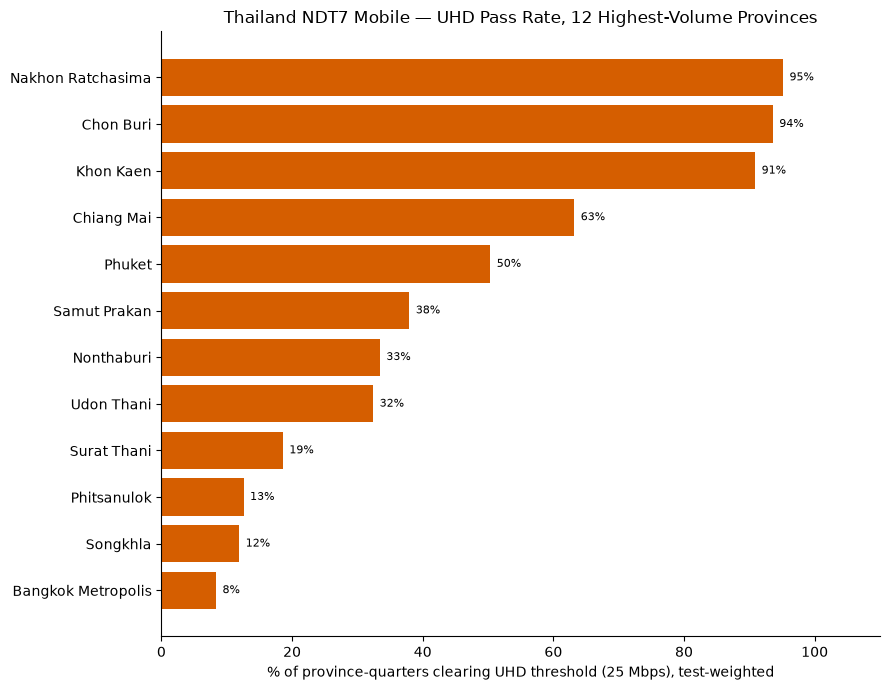

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
top_by_volume = prov_mobile.head(12).sort_values('UHD (25 Mbps)')
bars = ax.barh(top_by_volume.index, top_by_volume['UHD (25 Mbps)'], color='#D55E00', edgecolor='none')
for bar, val in zip(bars, top_by_volume['UHD (25 Mbps)']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}%', va='center', fontsize=8)
ax.set_xlabel('% of province-quarters clearing UHD threshold (25 Mbps), test-weighted')
ax.set_title('Thailand NDT7 Mobile — UHD Pass Rate, 12 Highest-Volume Provinces')
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Key Findings

- **Fixed-broadband threshold comparison now covers all 9 countries** (previously Thailand+Vietnam
  only) — see the small-multiples chart above for the full picture and the summary table for exact
  numbers plus sample sizes.
- **Cross-source ranking agreement** — see the Spearman result above; read it alongside
  `rq_stats_crosscountry.ipynb`'s OLS-coefficient-based version of the same check (different
  metric, same question).
- **NDT7 sample sizes are highly uneven across countries** — Thailand/Indonesia/Philippines have
  hundreds of reliable province-quarters, Cambodia/Laos/Myanmar have a few dozen. Any single
  country's NDT7 pass rate should be read next to its `n_province_quarters`, not in isolation.
- **This notebook's fixed-vs-mobile and Ookla-vs-NDT7 gap findings for Thailand specifically**
  (illustrative deep-dive above) carry over unchanged from the original 2-country version — nothing
  about Thailand's own numbers changed by adding the other 7 countries.
